<a href="https://colab.research.google.com/github/vaidiknakrani/parul_AI_ML_Learning/blob/main/Day_6_%E2%80%94_Notebook_3_Time_Series_Forecasting_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paulbrabban_daily_minimum_temperatures_in_melbourne_path = kagglehub.dataset_download('paulbrabban/daily-minimum-temperatures-in-melbourne')

print('Data source import complete.')


# Day 6 — Notebook 3: Time-Series Forecasting with LSTMs
## Slide 12: RNNs · LSTM Gates · Sequence Prediction

**Parul University & TelcoLearn | AI-ML Training Program 2027**  
**Day 6 | July 18, 2025 | 1:30 PM - 5:00 PM**

---

## What you will build

| Section | What you build | What you learn |
|---------|---------------|----------------|
| 1 | EDA + stationarity | Trend, seasonality, autocorrelation |
| 2 | Sliding window sequences | How sequential data is prepared |
| 3 | Baseline models | Naive, Linear Regression as lower bounds |
| 4 | Vanilla RNN | Why it fails on long sequences |
| 5 | LSTM | Gate equations → working model |
| 6 | Bidirectional LSTM | Both directions improve results |
| 7 | Window size experiment | 7 vs 30 vs 60 days |
| 8 | Final comparison | All models on one plot |

**Dataset:** Daily Minimum Temperatures Melbourne (1981--1990)  
**Kaggle path:** `/kaggle/input/daily-minimum-temperatures-in-me/daily-minimum-temperatures.csv`  
**Dataset URL:** https://www.kaggle.com/datasets/paulbrabban/daily-minimum-temperatures-in-melbourne  
**Task:** Univariate time-series — predict tomorrow's temperature given the past N days  
**GPU:** Optional for this notebook (fast enough on CPU)

---
> **Key concept:** Sequential data has **temporal dependencies** — yesterday's temperature
> tells you something about today's. RNNs model this through the hidden state.
> LSTMs add gating to retain information over **long time ranges**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print('All imports successful.')

Device: cuda
All imports successful.


Shape: (3647, 1)
Date range: 1981-01-01 00:00:00 to 1990-12-31 00:00:00
Temperature range: 0.0 to 26.3 deg C
            temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


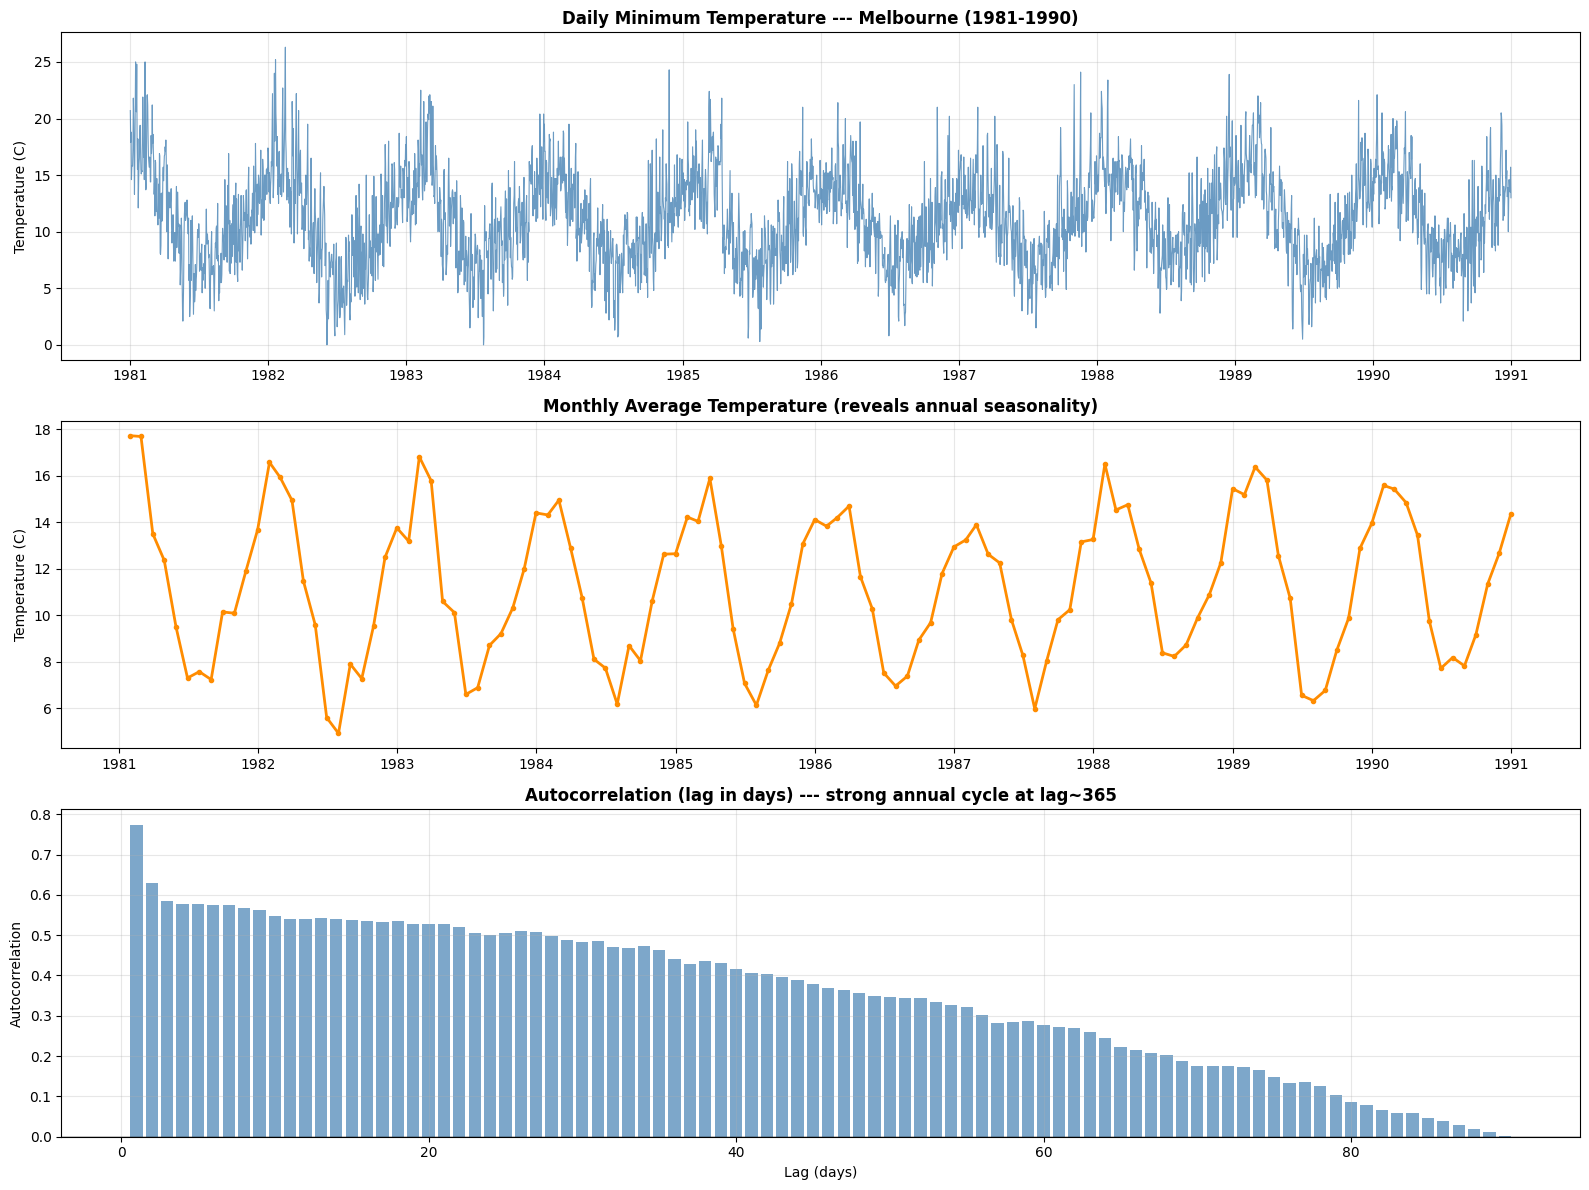

Key observation: strong annual seasonality (winter/summer cycle).
Autocorrelation at lag-1 is high -- yesterday predicts today.
Autocorrelation at lag-7 is moderate -- same day last week helps.


In [ ]:
# ── Load dataset ────────────────────────────────────────────────────────────
DATASET_PATH = '/kaggle/input/datasets/paulbrabban/daily-minimum-temperatures-in-melbourne'


df = pd.read_csv(f'{DATASET_PATH}/daily-minimum-temperatures-in-me.csv',
                 parse_dates=['Date'], index_col='Date',on_bad_lines = 'skip')
df.columns = ['temp']
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
df.dropna(inplace=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Temperature range: {df["temp"].min():.1f} to {df["temp"].max():.1f} deg C')
print(df.head())

# ── EDA ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full series
axes[0].plot(df.index, df['temp'], 'steelblue', linewidth=0.8, alpha=0.8)
axes[0].set_title('Daily Minimum Temperature --- Melbourne (1981-1990)',
                   fontweight='bold')
axes[0].set_ylabel('Temperature (C)')
axes[0].grid(True, alpha=0.3)

# Monthly averages to show seasonality
monthly = df['temp'].resample('M').mean()
axes[1].plot(monthly.index, monthly.values, 'darkorange', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Monthly Average Temperature (reveals annual seasonality)', fontweight='bold')
axes[1].set_ylabel('Temperature (C)')
axes[1].grid(True, alpha=0.3)

# Autocorrelation: how much does today's temp predict future temps?
lags = range(1, 91)
autocorr = [df['temp'].autocorr(lag=lag) for lag in lags]
axes[2].bar(lags, autocorr, color='steelblue', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Autocorrelation (lag in days) --- strong annual cycle at lag~365',
                   fontweight='bold')
axes[2].set_xlabel('Lag (days)'); axes[2].set_ylabel('Autocorrelation')
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('Key observation: strong annual seasonality (winter/summer cycle).')
print('Autocorrelation at lag-1 is high -- yesterday predicts today.')
print('Autocorrelation at lag-7 is moderate -- same day last week helps.')

In [ ]:
# ── Prepare sliding window sequences ────────────────────────────────────────
def make_sequences(series, window_size):
    """Convert a 1D time series into (X, y) pairs using a sliding window.
    X: past `window_size` values. y: the next value.
    """
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

# Scale to [0, 1] -- important for RNN/LSTM stability
scaler = MinMaxScaler()
values = scaler.fit_transform(df[['temp']]).flatten()

WINDOW = 30  # use last 30 days to predict the next day
X_all, y_all = make_sequences(values, WINDOW)

# Chronological split (NO shuffle for time series!)
n        = len(X_all)
n_train  = int(n * 0.70)
n_val    = int(n * 0.85)

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_val], y_all[n_train:n_val]
X_test,  y_test  = X_all[n_val:], y_all[n_val:]

print(f'Window size: {WINDOW} days')
print(f'Train: {len(X_train)} sequences')
print(f'Val:   {len(X_val)} sequences')
print(f'Test:  {len(X_test)} sequences')
print(f'X shape: {X_train.shape}  (sequences x window)')
print()
print('IMPORTANT: No shuffling for time series!')
print('Shuffling would leak future data into training -- always use chronological split.')

Window size: 30 days
Train: 2531 sequences
Val:   543 sequences
Test:  543 sequences
X shape: (2531, 30)  (sequences x window)

IMPORTANT: No shuffling for time series!
Shuffling would leak future data into training -- always use chronological split.


In [ ]:
# ── Baseline 1: Naive (predict yesterday) ───────────────────────────────────
y_naive = X_test[:, -1]  # predict last value in window as tomorrow's value
naive_rmse = np.sqrt(mean_squared_error(y_test, y_naive))
naive_mae  = mean_absolute_error(y_test, y_naive)

# ── Baseline 2: Linear Regression ───────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_lr     = lr.predict(X_test)
lr_rmse  = np.sqrt(mean_squared_error(y_test, y_lr))
lr_mae   = mean_absolute_error(y_test, y_lr)

results = {
    'Naive (yesterday)' : {'rmse': naive_rmse, 'mae': naive_mae, 'preds': y_naive},
    'Linear Regression' : {'rmse': lr_rmse,    'mae': lr_mae,    'preds': y_lr},
}

print('=== BASELINE RESULTS (normalised scale) ===')
print(f'{"Model":<22} {"RMSE":>8} {"MAE":>8}')
print('-'*40)
for name, res in results.items():
    print(f'{name:<22} {res["rmse"]:>8.5f} {res["mae"]:>8.5f}')
print()
print('These are normalised (scaled) values.')
print('Any deep learning model MUST beat Linear Regression to be worth deploying.')

=== BASELINE RESULTS (normalised scale) ===
Model                      RMSE      MAE
----------------------------------------
Naive (yesterday)       0.09796  0.07746
Linear Regression       0.08527  0.06637

These are normalised (scaled) values.
Any deep learning model MUST beat Linear Regression to be worth deploying.


## Section 4 — LSTM Implementation

We implement the LSTM gate equations from the slide:

- **Forget gate**: $f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$  
- **Input gate**: $i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)$  
- **Cell candidate**: $\tilde{c}_t = \tanh(W_c[h_{t-1}, x_t] + b_c)$  
- **Cell update**: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$  
- **Output gate**: $o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)$  
- **Hidden state**: $h_t = o_t \odot \tanh(c_t)$

PyTorch's `nn.LSTM` implements all of this internally.

In [ ]:
class TimeSeriesModel(nn.Module):
    """Flexible model: Vanilla RNN, LSTM, or Bidirectional LSTM."""
    def __init__(self, model_type='lstm', hidden_size=64, num_layers=2,
                 window_size=30, dropout=0.2):
        super().__init__()
        self.model_type = model_type

        if model_type == 'rnn':
            self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size,
                              num_layers=num_layers, batch_first=True,
                              dropout=dropout if num_layers > 1 else 0)
        elif model_type == 'lstm':
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_size,
                               num_layers=num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        elif model_type == 'bilstm':
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_size,
                               num_layers=num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0,
                               bidirectional=True)

        factor = 2 if model_type == 'bilstm' else 1
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * factor, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, window, 1)
        out, _ = self.rnn(x)   # out: (batch, window, hidden)
        last   = out[:, -1, :]  # take the last time step output
        return self.fc(last).squeeze(-1)

def train_ts_model(model_type='lstm', window=30, epochs=50, hidden=64,
                   num_layers=2, verbose=True):
    """Train a time-series model and return results."""
    # Prepare data: shape needs to be (batch, seq_len, 1) for LSTM
    X_tr = torch.FloatTensor(X_train).unsqueeze(-1).to(DEVICE)  # add feature dim
    y_tr = torch.FloatTensor(y_train).to(DEVICE)
    X_v  = torch.FloatTensor(X_val).unsqueeze(-1).to(DEVICE)
    y_v  = torch.FloatTensor(y_val).to(DEVICE)
    X_te = torch.FloatTensor(X_test).unsqueeze(-1).to(DEVICE)

    ds  = TensorDataset(X_tr, y_tr)
    dl  = DataLoader(ds, batch_size=64, shuffle=True)

    model = TimeSeriesModel(model_type, hidden, num_layers, window).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
    crit  = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val, best_weights = float('inf'), None

    for epoch in range(epochs):
        model.train()
        batch_l = []
        for Xb, yb in dl:
            opt.zero_grad()
            pred = model(Xb)
            loss = crit(pred, yb)
            loss.backward(); opt.step()
            batch_l.append(loss.item())
        tl = np.mean(batch_l)

        model.eval()
        with torch.no_grad():
            vl = crit(model(X_v), y_v).item()
        train_losses.append(tl); val_losses.append(vl)
        sched.step(vl)

        if vl < best_val:
            best_val = vl
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}: train={tl:.5f}  val={vl:.5f}')

    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        test_preds = model(X_te).cpu().numpy()
    rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    mae  = mean_absolute_error(y_test, test_preds)
    return test_preds, train_losses, val_losses, rmse, mae

print('Model classes ready. Training will start in the next cells.')

Model classes ready. Training will start in the next cells.


In [ ]:
# ── Train Vanilla RNN ───────────────────────────────────────────────────────
print('Training Vanilla RNN...')
rnn_preds, rnn_trl, rnn_vl, rnn_rmse, rnn_mae = train_ts_model('rnn', epochs=60)
results['Vanilla RNN'] = {'rmse': rnn_rmse, 'mae': rnn_mae, 'preds': rnn_preds}
print(f'Vanilla RNN -> RMSE: {rnn_rmse:.5f}  MAE: {rnn_mae:.5f}')

# ── Train LSTM ──────────────────────────────────────────────────────────────
print('\nTraining LSTM (2 layers)...')
lstm_preds, lstm_trl, lstm_vl, lstm_rmse, lstm_mae = train_ts_model('lstm', epochs=80)
results['LSTM (2-layer)'] = {'rmse': lstm_rmse, 'mae': lstm_mae, 'preds': lstm_preds}
print(f'LSTM -> RMSE: {lstm_rmse:.5f}  MAE: {lstm_mae:.5f}')

# ── Train Bidirectional LSTM ─────────────────────────────────────────────────
print('\nTraining Bidirectional LSTM...')
bi_preds, bi_trl, bi_vl, bi_rmse, bi_mae = train_ts_model('bilstm', epochs=80)
results['BiLSTM'] = {'rmse': bi_rmse, 'mae': bi_mae, 'preds': bi_preds}

Training Vanilla RNN...
  Epoch   0: train=0.04654  val=0.02544
  Epoch  10: train=0.01125  val=0.00815
  Epoch  20: train=0.01039  val=0.00798
  Epoch  30: train=0.01001  val=0.00827
  Epoch  40: train=0.00965  val=0.00793
  Epoch  50: train=0.00948  val=0.00784
Vanilla RNN -> RMSE: 0.08474  MAE: 0.06576

Training LSTM (2 layers)...
  Epoch   0: train=0.06912  val=0.02011
  Epoch  10: train=0.01377  val=0.01098
  Epoch  20: train=0.01262  val=0.00926
  Epoch  30: train=0.01117  val=0.00805
  Epoch  40: train=0.01056  val=0.00788
  Epoch  50: train=0.01021  val=0.00806
  Epoch  60: train=0.00998  val=0.00796
  Epoch  70: train=0.00971  val=0.00784
LSTM -> RMSE: 0.08465  MAE: 0.06598

Training Bidirectional LSTM...
  Epoch   0: train=0.08440  val=0.02235
  Epoch  10: train=0.01273  val=0.01035
  Epoch  20: train=0.01123  val=0.00847
  Epoch  30: train=0.01137  val=0.00813
  Epoch  40: train=0.01091  val=0.00822
  Epoch  50: train=0.01023  val=0.00802
  Epoch  60: train=0.00999  val=0.00

In [ ]:
# ── Window size experiment ───────────────────────────────────────────────────
print('Window size experiment: 7 vs 30 vs 60 days...')
window_results = {}
for win in [7, 30, 60]:
    X_w, y_w = make_sequences(values, win)
    # Redo splits for this window size
    nw = len(X_w)
    nwtr = int(nw * 0.70); nwv = int(nw * 0.85)
    global X_train, y_train, X_val, y_val, X_test, y_test
    X_train, y_train = X_w[:nwtr], y_w[:nwtr]
    X_val,   y_val   = X_w[nwtr:nwv], y_w[nwtr:nwv]
    X_test,  y_test  = X_w[nwv:], y_w[nwv:]
    preds, _, _, rmse, mae = train_ts_model('lstm', window=win, epochs=60, verbose=False)
    window_results[win] = {'rmse': rmse, 'mae': mae}
    print(f'  Window={win:2d} days: RMSE={rmse:.5f}  MAE={mae:.5f}')

# Reset to window=30
X_all, y_all = make_sequences(values, 30)
n = len(X_all); n_train = int(n*0.70); n_val = int(n*0.85)
X_train, y_train = X_all[:n_train], y_all[:n_train]
X_val, y_val     = X_all[n_train:n_val], y_all[n_train:n_val]
X_test, y_test   = X_all[n_val:], y_all[n_val:]

Window size experiment: 7 vs 30 vs 60 days...
  Window= 7 days: RMSE=0.08608  MAE=0.06656
  Window=30 days: RMSE=0.08475  MAE=0.06587
  Window=60 days: RMSE=0.08513  MAE=0.06616


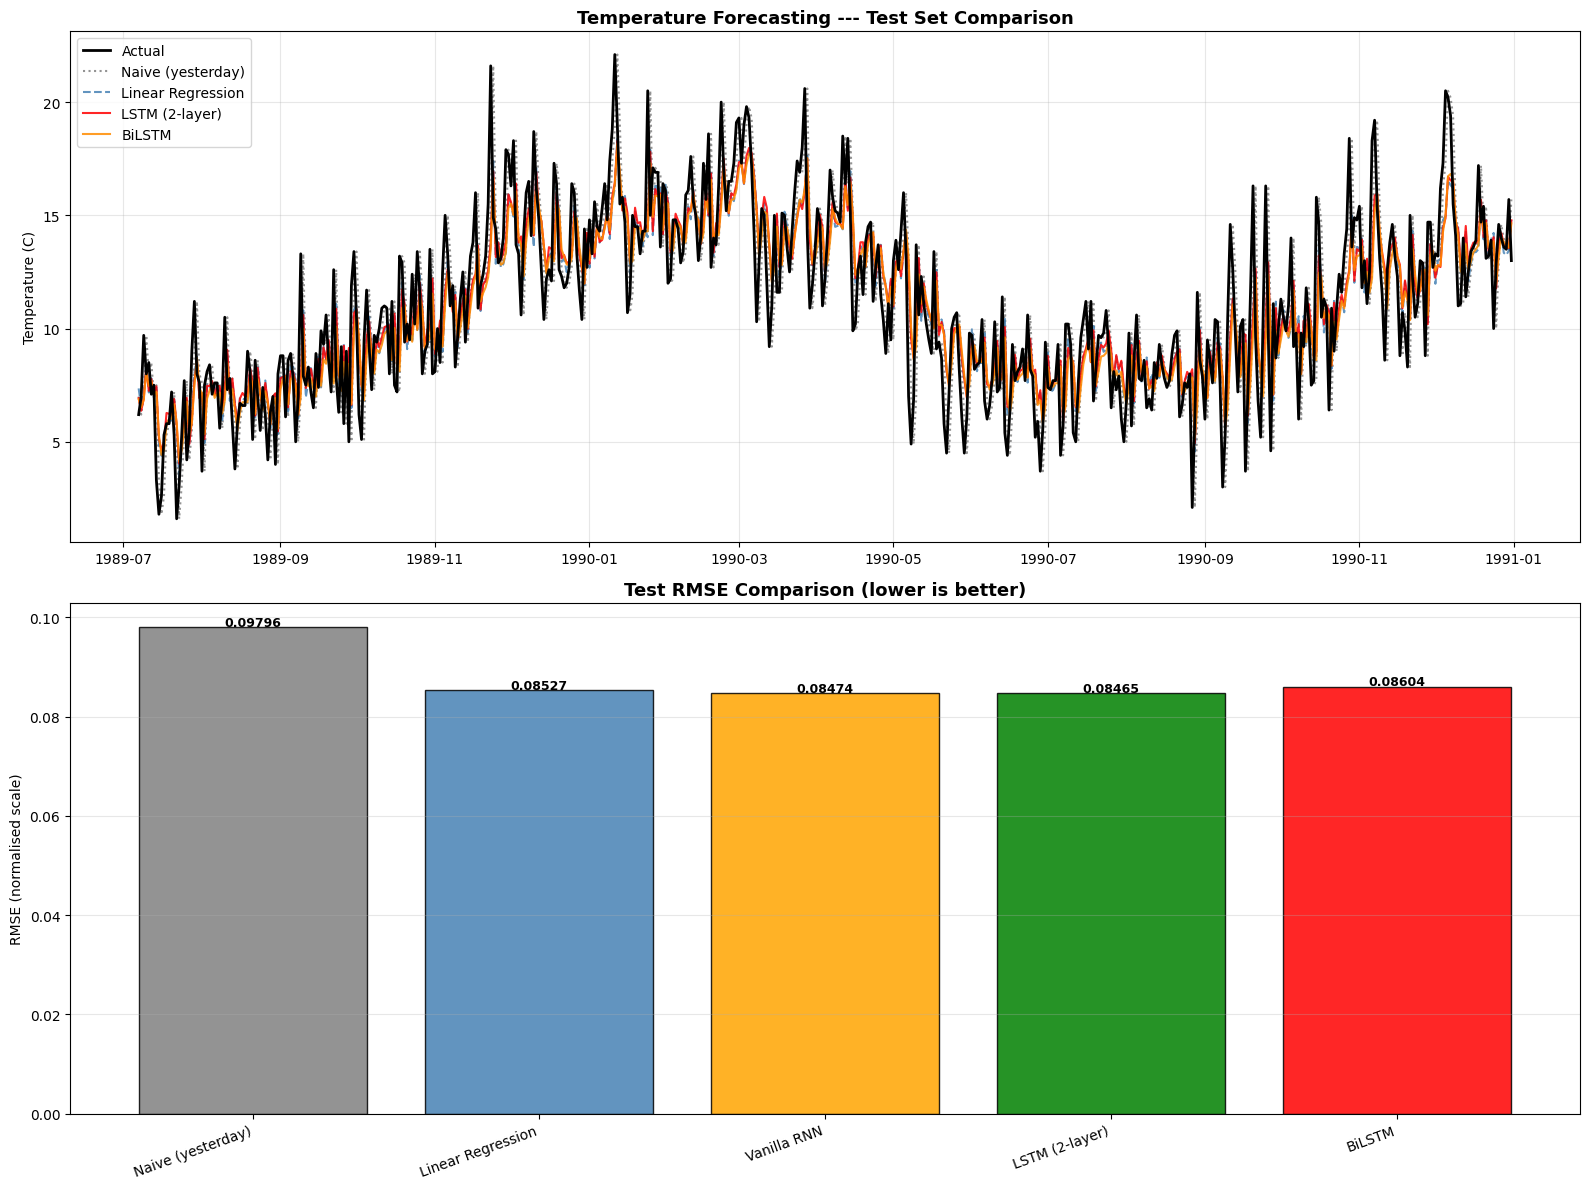

  DAY 6 NOTEBOOK 3 - LSTM FORECASTING RESULTS
  Dataset: Daily Minimum Temperatures Melbourne
  Naive (yesterday)       : RMSE=0.09796  MAE=0.07746
  Linear Regression       : RMSE=0.08527  MAE=0.06637
  Vanilla RNN             : RMSE=0.08474  MAE=0.06576
  LSTM (2-layer)          : RMSE=0.08465  MAE=0.06598
  BiLSTM                  : RMSE=0.08604  MAE=0.06689

Window size experiment:
  Window= 7 days: RMSE=0.08608
  Window=30 days: RMSE=0.08475
  Window=60 days: RMSE=0.08513

Key lessons:
  1. Always use chronological split for time series -- no shuffle!
  2. Vanilla RNN fails for sequences > ~10 steps (vanishing gradient).
  3. LSTM gates (forget/input/output) explicitly control what to remember.
  4. BiLSTM reads sequences in both directions -- better for classification
     tasks where the full sequence is available. NOT for real-time forecasting.
  5. Scale time series to [0,1] before LSTM -- MinMaxScaler, fit on train only.


In [ ]:
# ── Final comparison plot ────────────────────────────────────────────────────
# Inverse transform predictions to original temperature scale
def inv(arr):
    return scaler.inverse_transform(arr.reshape(-1,1)).flatten()

y_test_orig = inv(y_test)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Predictions on test set
ax = axes[0]
test_dates = df.index[-len(y_test):]
ax.plot(test_dates, y_test_orig, 'black', linewidth=2, label='Actual', zorder=5)

plot_models = [
    ('Naive (yesterday)', results['Naive (yesterday)']['preds'], 'gray',      ':'),
    ('Linear Regression', results['Linear Regression']['preds'], 'steelblue', '--'),
    ('LSTM (2-layer)',    results['LSTM (2-layer)']['preds'],    'red',       '-'),
    ('BiLSTM',           results['BiLSTM']['preds'],            'darkorange', '-'),
]
for name, preds, color, ls in plot_models:
    ax.plot(test_dates, inv(preds), color=color, linewidth=1.5,
            linestyle=ls, label=name, alpha=0.85)
ax.set_title('Temperature Forecasting --- Test Set Comparison', fontweight='bold', fontsize=13)
ax.set_ylabel('Temperature (C)'); ax.legend(); ax.grid(True, alpha=0.3)

# Bar chart of RMSE
ax2 = axes[1]
all_models = list(results.keys()) + ['BiLSTM']
all_rmse   = [results[k]['rmse'] if k in results else bi_rmse for k in all_models]
# Deduplicate
model_names_bar = list(results.keys())
rmse_bar = [results[k]['rmse'] for k in model_names_bar]
colors_bar = ['gray','steelblue','orange','green','red','purple']
bars = ax2.bar(model_names_bar, rmse_bar,
               color=colors_bar[:len(model_names_bar)],
               edgecolor='black', alpha=0.85)
for bar, val in zip(bars, rmse_bar):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
             f'{val:.5f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Test RMSE Comparison (lower is better)', fontweight='bold', fontsize=13)
ax2.set_ylabel('RMSE (normalised scale)')
ax2.set_xticklabels(model_names_bar, rotation=20, ha='right')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print('='*60)
print('  DAY 6 NOTEBOOK 3 - LSTM FORECASTING RESULTS')
print('  Dataset: Daily Minimum Temperatures Melbourne')
print('='*60)
for name, res in results.items():
    print(f'  {name:<24}: RMSE={res["rmse"]:.5f}  MAE={res["mae"]:.5f}')
print()
print('Window size experiment:')
for win, res in window_results.items():
    print(f'  Window={win:2d} days: RMSE={res["rmse"]:.5f}')
print()
print('Key lessons:')
print('  1. Always use chronological split for time series -- no shuffle!')
print('  2. Vanilla RNN fails for sequences > ~10 steps (vanishing gradient).')
print('  3. LSTM gates (forget/input/output) explicitly control what to remember.')
print('  4. BiLSTM reads sequences in both directions -- better for classification')
print('     tasks where the full sequence is available. NOT for real-time forecasting.')
print('  5. Scale time series to [0,1] before LSTM -- MinMaxScaler, fit on train only.')